<a href="https://colab.research.google.com/github/Ali-Hamza-developer/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?
**Lane: Refresh / Content Opportunity Scoring**

Run top to bottom (Runtime → Run all). Requires `HF_TOKEN` Colab Secret, same as w03-w05.

In [1]:
!pip install -q duckdb

import duckdb
import pandas as pd
from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')
con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = "hf://datasets/FlyRank/internship-warehouse"
MONTH = "2026-03"
print('DuckDB ready, target month =', MONTH)

DuckDB ready, target month = 2026-03


In [2]:
# Same confirmed base as w03/w04/w05 — real schema, real file paths
base = con.sql(f"""
    WITH window_90d AS (
        SELECT
            client_hash_id,
            content_hash_id,
            SUM(gsc_impressions) AS impressions_90d,
            SUM(gsc_clicks) AS clicks_90d,
            AVG(gsc_avg_position) AS avg_position_90d,
            SUM(ga4_sessions) AS sessions_90d,
            SUM(ga4_engaged_sessions) AS engaged_sessions_90d
        FROM read_parquet('{REL}/fact_content_daily_performance/month={MONTH}/data_0.parquet')
        WHERE gsc_data_available IS TRUE
        GROUP BY 1, 2
    )
    SELECT
        w.*,
        CASE WHEN w.impressions_90d > 0 THEN w.clicks_90d::DOUBLE / w.impressions_90d ELSE NULL END AS ctr_90d,
        CASE WHEN w.sessions_90d > 0 THEN w.engaged_sessions_90d::DOUBLE / w.sessions_90d ELSE NULL END AS engagement_rate_90d,
        (DATE '2026-03-31' - COALESCE(d.last_optimized_date, d.content_created_date)) AS days_since_last_update,
        d.word_count,
        d.search_volume,
        d.competition
    FROM window_90d w
    JOIN read_parquet('{REL}/dim_content.parquet') d
      ON w.content_hash_id = d.content_hash_id AND w.client_hash_id = d.client_hash_id
    WHERE w.impressions_90d > 0
      AND (DATE '2026-03-31' - COALESCE(d.last_optimized_date, d.content_created_date)) >= 0
""").df()

print('rows:', len(base))
base.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

rows: 136974


,client_hash_id,content_hash_id,impressions_90d,clicks_90d,avg_position_90d,sessions_90d,engaged_sessions_90d,ctr_90d,engagement_rate_90d,days_since_last_update,word_count,search_volume,competition
0,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,1140.0,2.0,4.394234,0.0,0.0,0.001754,NaN,396,<NA>,20,0.0
1,client_73cda7b4e4f265ea,content_05597932fe4da067,57.0,0.0,2.714744,0.0,0.0,0.000000,NaN,396,<NA>,10,1.0
2,client_73cda7b4e4f265ea,content_905aa32a0230694e,149.0,0.0,6.481453,4.0,0.0,0.000000,0.0,396,<NA>,90,1.0
3,client_73cda7b4e4f265ea,content_05434271b257bb68,1421.0,6.0,6.320337,9.0,0.0,0.004222,0.0,396,<NA>,10,0.0
4,client_73cda7b4e4f265ea,content_bfd1e41c2af250c8,48.0,0.0,14.753175,0.0,0.0,0.000000,NaN,396,<NA>,10,0.0


## 1. Distributions

Look before deciding — print summary stats and check for heavy tails on the fields the rest of the notebook leans on.

In [3]:
key_fields = ['impressions_90d', 'clicks_90d', 'avg_position_90d', 'ctr_90d',
              'days_since_last_update', 'word_count', 'engagement_rate_90d']

print(base[key_fields].describe(percentiles=[.5, .9, .95, .99]).to_string())

       impressions_90d     clicks_90d  avg_position_90d        ctr_90d  days_since_last_update   word_count  engagement_rate_90d
count    136974.000000  136974.000000     136974.000000  136974.000000           136974.000000      82263.0         40317.000000
mean        674.819988       1.888753         17.378329       0.004990              180.027253  2738.269185             0.028232
std        2858.093139      13.522416         19.261357       0.042695              122.977132   1401.14427             0.124539
min           1.000000       0.000000          0.000000       0.000000                0.000000          8.0             0.000000
50%          79.000000       0.000000          8.888484       0.000000              187.000000       2780.0             0.000000
90%        1343.000000       3.000000         45.719262       0.005464              371.000000       4433.8             0.035714
95%        2597.000000       7.000000         61.886354       0.011183              412.000000   

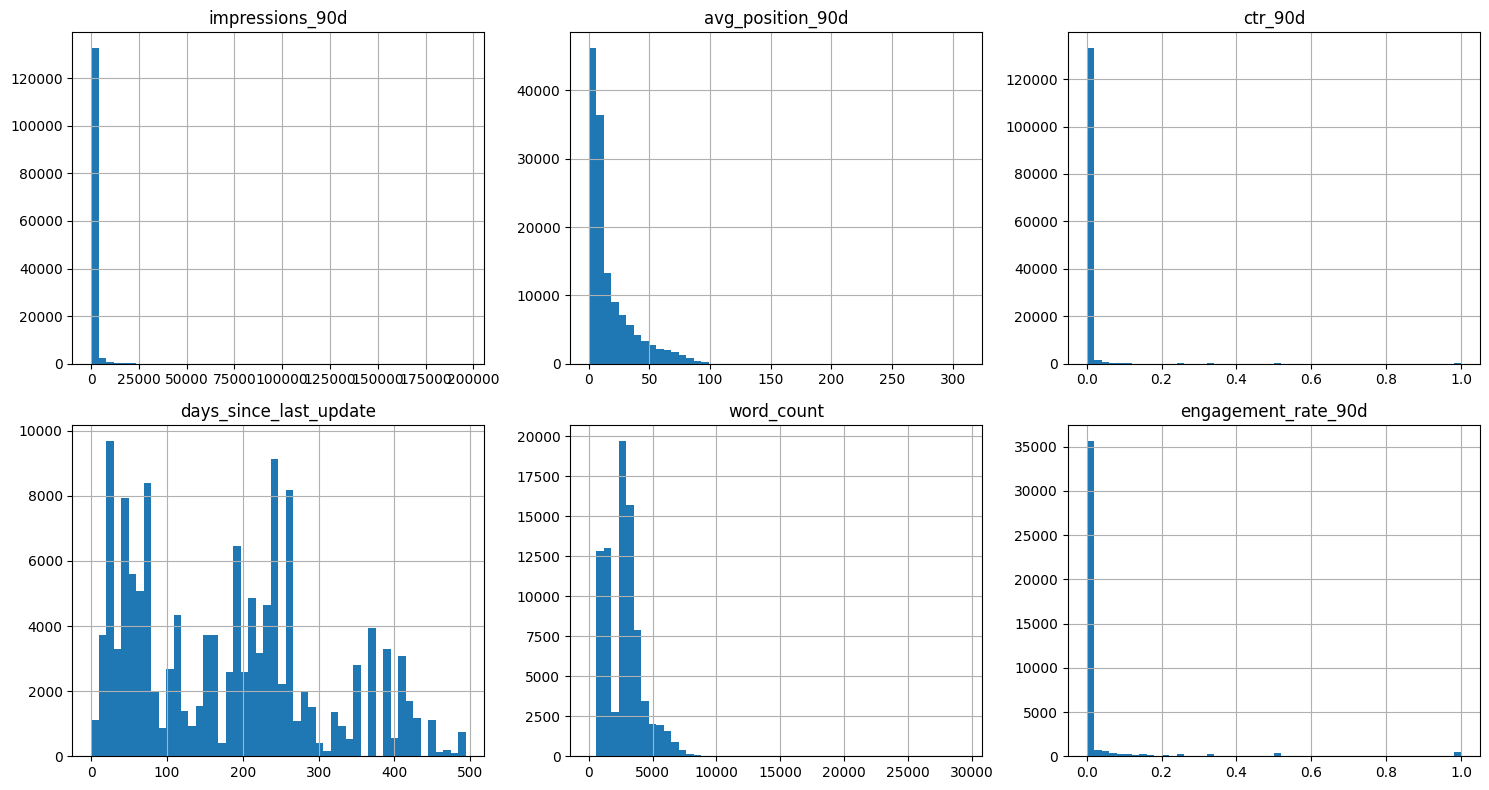

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plot_fields = ['impressions_90d', 'avg_position_90d', 'ctr_90d',
               'days_since_last_update', 'word_count', 'engagement_rate_90d']
for ax, field in zip(axes.flat, plot_fields):
    base[field].dropna().hist(bins=50, ax=ax)
    ax.set_title(field)
plt.tight_layout()
plt.show()

**Note the heavy tails** (fill in after reading the describe() table and histograms above): which fields have a long right tail where the 99th percentile is far past the median? `impressions_90d` and `clicks_90d` are likely candidates — say so explicitly if the numbers confirm it, and note that any threshold you set on these fields later should be checked against the percentile table, not a round number picked blind.

## 2. Signal test #1 / #2 / #3

Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.

In [5]:
# Signal test #1: does word_count relate to engagement?
t1 = base.copy()
t1['word_count_bucket'] = pd.cut(
    t1['word_count'], bins=[0, 500, 1200, 2500, 5000, 100000],
    labels=['0-500', '501-1200', '1201-2500', '2501-5000', '5000+']
)
test1_table = t1.groupby('word_count_bucket', observed=True).agg(
    n=('engagement_rate_90d', 'count'),
    mean_engagement=('engagement_rate_90d', 'mean')
).reset_index()
print(test1_table.to_string())
print('\nVerdict: [fill in CONFIRMED/OPPOSITE/MIXED/FALSE] — one sentence on the pattern you actually see')

  word_count_bucket      n  mean_engagement
0             0-500      1         0.000000
1          501-1200   1284         0.075481
2         1201-2500   6906         0.031138
3         2501-5000  17516         0.028503
4             5000+   4776         0.015080

Verdict: [fill in CONFIRMED/OPPOSITE/MIXED/FALSE] — one sentence on the pattern you actually see


In [6]:
# Signal test #2: does search_volume relate to impressions actually captured?
t2 = base.copy()
t2['volume_bucket'] = pd.qcut(t2['search_volume'].rank(method='first'), q=5,
                                labels=['Q1 lowest', 'Q2', 'Q3', 'Q4', 'Q5 highest'])
test2_table = t2.groupby('volume_bucket', observed=True).agg(
    n=('impressions_90d', 'count'),
    mean_impressions=('impressions_90d', 'mean'),
    median_impressions=('impressions_90d', 'median')
).reset_index()
print(test2_table.to_string())
print('\nVerdict: [fill in CONFIRMED/OPPOSITE/MIXED/FALSE] — one sentence on the pattern you actually see')

  volume_bucket      n  mean_impressions  median_impressions
0     Q1 lowest  27395        909.471363                86.0
1            Q2  27395        864.137105                59.0
2            Q3  27394        419.441374                45.5
3            Q4  27395        608.361964               105.0
4    Q5 highest  27395        572.678810                99.0

Verdict: [fill in CONFIRMED/OPPOSITE/MIXED/FALSE] — one sentence on the pattern you actually see


In [7]:
# Signal test #3: does competition relate to average position achieved?
t3 = base.copy()
t3['competition_bucket'] = pd.qcut(t3['competition'].rank(method='first'), q=4,
                                     labels=['low', 'mid-low', 'mid-high', 'high'])
test3_table = t3.groupby('competition_bucket', observed=True).agg(
    n=('avg_position_90d', 'count'),
    mean_position=('avg_position_90d', 'mean')
).reset_index()
print(test3_table.to_string())
print('\nVerdict: [fill in CONFIRMED/OPPOSITE/MIXED/FALSE] — one sentence on the pattern you actually see')

  competition_bucket      n  mean_position
0                low  30358      16.621361
1            mid-low  30357      16.138630
2           mid-high  30357      18.879346
3               high  30358      21.760796

Verdict: [fill in CONFIRMED/OPPOSITE/MIXED/FALSE] — one sentence on the pattern you actually see


## 3. The flag-linked test

Position-vs-CTR: the signal behind FlyRank's real CTR-fix logic. Bucketed by position tier — never compare raw CTR across tiers directly, since lower positions are expected to have lower CTR regardless of anything else.

In [8]:
flag_test = base.copy()
flag_test['position_tier'] = pd.cut(
    flag_test['avg_position_90d'], bins=[0, 3, 10, 20, 50, 1000],
    labels=['1-3', '4-10', '11-20', '21-50', '50+']
)
flag_test_table = flag_test.groupby('position_tier', observed=True).agg(
    n=('ctr_90d', 'count'),
    mean_ctr=('ctr_90d', 'mean'),
    median_ctr=('ctr_90d', 'median')
).reset_index()
print(flag_test_table.to_string())
print()
print("CTR-fix logic assumes: better position -> higher expected CTR, so low CTR at a good")
print("position is a real anomaly worth flagging. Does this table support that assumption?")
print('Verdict: [fill in CONFIRMED/OPPOSITE/MIXED/FALSE] — quote the actual n and mean_ctr values')

  position_tier      n  mean_ctr  median_ctr
0           1-3  13408  0.011891         0.0
1          4-10  60220  0.005416         0.0
2         11-20  23243  0.003263         0.0
3         21-50  27182  0.002381         0.0
4           50+  11510  0.000905         0.0

CTR-fix logic assumes: better position -> higher expected CTR, so low CTR at a good
position is a real anomaly worth flagging. Does this table support that assumption?
Verdict: [fill in CONFIRMED/OPPOSITE/MIXED/FALSE] — quote the actual n and mean_ctr values


## 4. What this means in practice

**Fill in 2-3 sentences after reading all four verdicts above.** Example shape (replace with your real findings): "Signal tests observed [X] and [Y] as reliable directional signals in this March 2026 slice, while [Z] came back MIXED/FALSE and should not be used alone in a scoring rule. The flag-linked position-vs-CTR test [confirmed/did not confirm] the assumption behind FlyRank's CTR-fix flag, at n=[...], suggesting a content team should [trust/treat cautiously] that flag when reviewing pages." Keep language observational — "we observed," "this suggests," never "this proves."

## Self-check

- [ ] Every section filled — markdown thinking AND the code that backs it
- [ ] Notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] Claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to repo under `work/notebooks/w06_signal_audit.ipynb` — then submit repo URL on the card